In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadaqeelkabir/top-anime-csv/top_anime_dataset.csv


#  Install & Import Libraries

In [2]:
!pip install --quiet pandas numpy matplotlib seaborn plotly scikit-learn xgboost catboost nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import mean_squared_error, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from math import sqrt
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#  Load Dataset

In [3]:

df = pd.read_csv("/kaggle/input/datasets/muhammadaqeelkabir/top-anime-csv/top_anime_dataset.csv")


#  Data Cleaning & Preprocessing

In [4]:
# Fill missing values safely without inplace
df['episodes'] = df['episodes'].fillna(0)
df['score'] = df['score'].fillna(df['score'].mean())
df['genres'] = df['genres'].fillna('Unknown')
df['studios'] = df['studios'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['year'] = df['year'].fillna(0)
df['members'] = df['members'].fillna(df['members'].median())
df['favorites'] = df['favorites'].fillna(0)

# Convert genres and studios to lists
df['genres_list'] = df['genres'].apply(lambda x: [i.strip() for i in x.split(',')] if x != 'Unknown' else [])
df['studios_list'] = df['studios'].apply(lambda x: [i.strip() for i in x.split(',')] if x != 'Unknown' else [])

# Encode categorical variables
le_type = LabelEncoder()
df['type_enc'] = le_type.fit_transform(df['type'].fillna('Unknown'))

le_source = LabelEncoder()
df['source_enc'] = le_source.fit_transform(df['source'].fillna('Unknown'))

le_rating = LabelEncoder()
df['rating_enc'] = le_rating.fit_transform(df['rating'].fillna('Unknown'))

#  Feature Engineering

In [5]:
#  Text Features (Synopsis)
df['synopsis'] = df['synopsis'].fillna('')
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['synopsis'])
svd = TruncatedSVD(n_components=200, random_state=42)
synopsis_features = svd.fit_transform(tfidf_matrix)

#  Numerical Features
num_features = df[['episodes', 'members', 'favorites', 'type_enc', 'source_enc', 'rating_enc', 'year']].values

# Combine features for modeling
X = np.hstack([num_features, synopsis_features])

# Multi-label encoding for genres
mlb = MultiLabelBinarizer()
y_genres = mlb.fit_transform(df['genres_list'])

# Rating classification target
y_rating = df['rating_enc']

# Score regression target
y_score = df['score'].values

# Exploratory Data Analysis

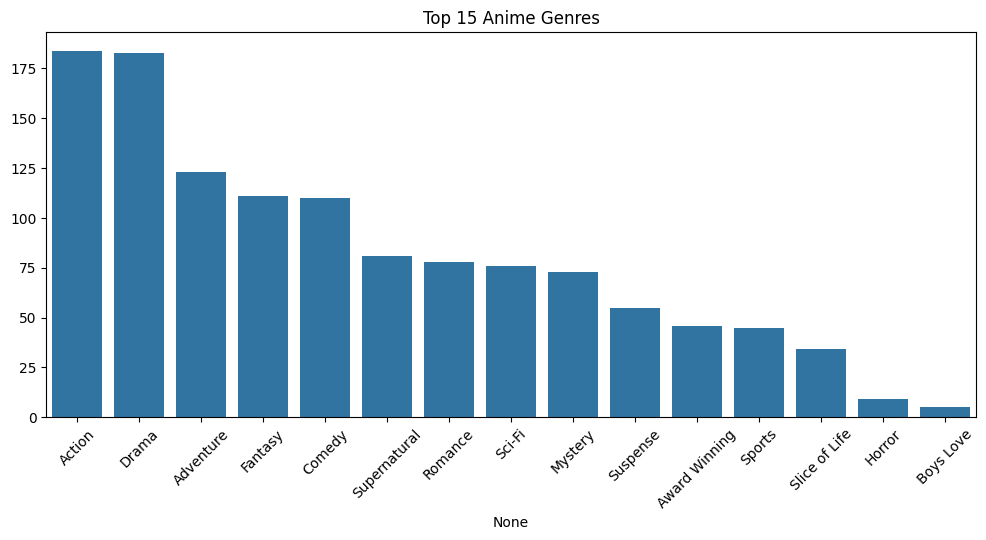

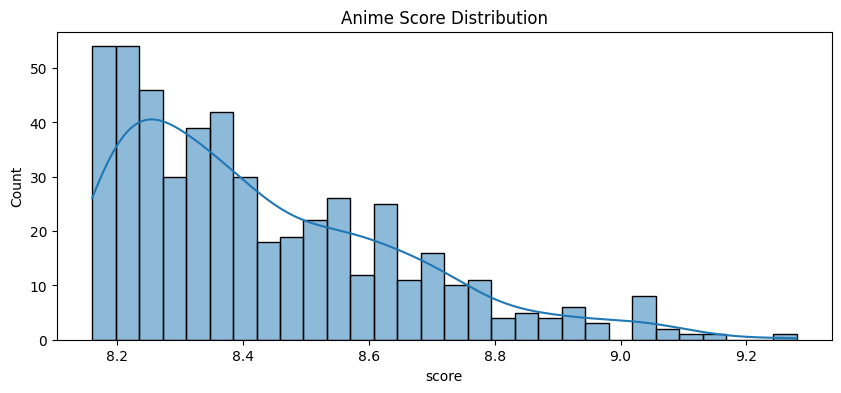

In [6]:
# Interactive Plot: Score vs Members
fig = px.scatter(df, x='members', y='score', color='type', hover_data=['title'])
fig.update_layout(title='Score vs Members by Anime Type', xaxis_type='log')
fig.show()

# Top genres
genre_counts = pd.Series([g for sublist in df['genres_list'] for g in sublist]).value_counts()
plt.figure(figsize=(12,5))
sns.barplot(x=genre_counts.index[:15], y=genre_counts.values[:15])
plt.xticks(rotation=45)
plt.title('Top 15 Anime Genres')
plt.show()

# Score distribution
plt.figure(figsize=(10,4))
sns.histplot(df['score'], bins=30, kde=True)
plt.title('Anime Score Distribution')
plt.show()


#  Multi-Model Training

In [7]:
#  Regression: Predict Score
X_train, X_test, y_train, y_test = train_test_split(X, y_score, test_size=0.2, random_state=42)

models_reg = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
}

for name, model in models_reg.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, preds))  # Fixed for older sklearn
    print(f"{name} RMSE: {rmse:.3f}")

#  Classification: Predict Rating
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_rating, test_size=0.2, random_state=42)
models_clf = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, iterations=200, random_state=42)
}

for name, model in models_clf.items():
    model.fit(X_train_r, y_train_r)
    preds = model.predict(X_test_r)
    print(f"{name} Classification Report:\n", classification_report(y_test_r, preds))

#  Multi-Label Classification: Predict Genres
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X, y_genres, test_size=0.2, random_state=42)
ml_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, random_state=42))
ml_model.fit(X_train_g, y_train_g)
y_pred_g = ml_model.predict(X_test_g)
print("Multi-Label Genre Prediction Accuracy:", (y_pred_g == y_test_g).mean())


LinearRegression RMSE: 0.260
RandomForest RMSE: 0.221
XGBoost RMSE: 0.227


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-p

LogisticRegression Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.58      0.56      0.57        63
           3       0.15      0.21      0.17        29
           4       0.00      0.00      0.00         4

    accuracy                           0.41       100
   macro avg       0.15      0.15      0.15       100
weighted avg       0.41      0.41      0.41       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



RandomForest Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.94      1.00      0.97        63
           3       0.88      1.00      0.94        29
           4       0.00      0.00      0.00         4

    accuracy                           0.92       100
   macro avg       0.36      0.40      0.38       100
weighted avg       0.85      0.92      0.88       100

CatBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00        63
           3       1.00      1.00      1.00        29
           4       1.00      1.00      1.00         4

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighte

#  Recommendation Engine

In [8]:
# Nearest Neighbors on synopsis SVD
nn_model = NearestNeighbors(n_neighbors=6, metric='cosine')
nn_model.fit(synopsis_features)

def recommend_content(title):
    idx = df.index[df['title']==title].tolist()[0]
    distances, indices = nn_model.kneighbors([synopsis_features[idx]])
    return df.iloc[indices[0][1:]]['title'].values

print("Content-Based Recommendations for 'Fullmetal Alchemist: Brotherhood':")
print(recommend_content("Fullmetal Alchemist: Brotherhood"))

#  Simple Collaborative Filtering: Cosine similarity on members
interaction_matrix = df[['mal_id', 'members']].copy()
interaction_matrix['user_id'] = 0  # single "community user"
interaction_matrix_pivot = interaction_matrix.pivot(index='user_id', columns='mal_id', values='members').fillna(0)
sim_matrix = cosine_similarity(interaction_matrix_pivot.T)
sim_df = pd.DataFrame(sim_matrix, index=interaction_matrix_pivot.columns, columns=interaction_matrix_pivot.columns)

def recommend_collab(mal_id, top_n=5):
    return sim_df[mal_id].sort_values(ascending=False).index[1:top_n+1]

print("Collaborative Recommendations for mal_id=5114 (Fullmetal Alchemist: Brotherhood):")
print(recommend_collab(5114))


Content-Based Recommendations for 'Fullmetal Alchemist: Brotherhood':
['Houseki no Kuni' 'ReLIFE: Kanketsu-hen' 'Romeo no Aoi Sora'
 'Danshi Koukousei no Nichijou' 'Yuukoku no Moriarty']
Collaborative Recommendations for mal_id=5114 (Fullmetal Alchemist: Brotherhood):
Index([1, 5, 6, 60058, 60022], dtype='int64', name='mal_id')
